In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
class DataPreprocessing:
    def __init__(self, train, test):
        self.target, self.column_drop = "ghi", "timestamp"
        self.train = train.dropna(subset=[self.target]).rename(columns={'Unnamed: 0': 'id'}) #[train[self.target] != 0]
        self.test = test.dropna(subset=[self.target]).rename(columns={'Unnamed: 0': 'id'}) #[test[self.target] != 0]

        self.feature_extraction()
        self.train_test_split()
        self.normalise_encode()

    def feature_extraction(self):
        train['timestamp'] = pandas.to_datetime(train['timestamp'])
        train['timestamp_year'] = train['timestamp'].dt.year
        train['timestamp_month'] = train['timestamp'].dt.month
        train['timestamp_day'] = train['timestamp'].dt.day

        train['timestamp_hour'] = train['timestamp'].dt.hour
        train['timestamp_minute'] = train['timestamp'].dt.minute
        train['timestamp_second'] = train['timestamp'].dt.second

    def train_test_split(self):
        self.train_x = self.train.drop(columns = [self.target, self.column_drop])
        self.train_y = self.train[self.target]

        self.test_x = self.test.drop(columns = [self.target, self.column_drop])
        self.test_y = self.test[self.target]

    def normalise_encode(self):
        encoder = LabelEncoder()
        normalize = SimpleImputer(strategy='mean')

        for i in zip(self.train_x.columns, self.train_x.dtypes):
            if i[1]=='O':
                self.train_x[i[0]] = self.train_x[i[0]].fillna('Unknown')
                self.train_x[i[0]] = encoder.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = encoder.transform(self.test_x[i[0]].to_numpy().reshape(-1,1))
            else:
                self.train_x[i[0]].fillna(self.train_x[i[0]].mean(), inplace=True)
                self.train_x[i[0]] = normalize.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = normalize.transform(self.test_x[i[0]].to_numpy().reshape(-1,1))

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

In [4]:
train_x

,id,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,horizontal_radiation_2,...,incident_radiation_1,incident_radiation_2,incident_radiation_4,incident_radiation_3,reflected_radiation_1,reflected_radiation_2,reflected_radiation_4,reflected_radiation_3,ambient_temperature,wind_speed
0,0.0,0.0,0.0,22.143874,21.766006,21.887832,166.493537,99.996814,0.000000,0.0,...,0.0,238.902877,0.0,204.510918,0.0,15.861283,0.0,15.84967,23.450315,0.000000
1,1.0,0.0,0.0,21.903667,21.491851,21.646608,257.272004,99.996272,0.000000,0.0,...,0.0,238.902877,0.0,204.510918,0.0,15.861283,0.0,15.84967,23.215215,0.000000
2,2.0,0.0,0.0,22.539134,22.290230,22.319763,212.567154,99.996691,0.000000,0.0,...,0.0,238.902877,0.0,204.510918,0.0,15.861283,0.0,15.84967,23.301205,0.000000
3,3.0,0.0,0.0,22.686070,22.513330,22.484921,157.928208,99.996403,0.000000,0.0,...,0.0,238.902877,0.0,204.510918,0.0,15.861283,0.0,15.84967,23.352792,1.832727
4,4.0,0.0,0.0,23.157860,22.858801,22.862068,142.271059,99.997145,0.000000,0.0,...,0.0,238.902877,0.0,204.510918,0.0,15.861283,0.0,15.84967,23.505781,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,2177.0,0.0,0.0,24.549827,25.170659,-167.450346,192.120947,99.524041,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,26.100615,2.262000
2178,2178.0,0.0,0.0,23.955803,24.596405,-166.629780,183.957463,99.527953,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,25.603672,2.681591
2179,2179.0,0.0,0.0,23.831501,24.255848,-167.899599,192.255691,99.708108,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,25.550872,2.980141
2180,2180.0,0.0,0.0,23.394107,24.458971,-169.207935,182.341914,99.998124,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.00000,25.133733,2.382595


In [5]:
class solo_models:
    def __new__(self, train_X, train_y):
        print('INITIATING PARAMETER')
        self.X_train, self.y_train = train_X, train_y
        
        self.LGBM_R_parm = {'colsample_bytree': 0.7988997727163004,
                            'drop_rate': 0.2968017716958511,
                            'learning_rate': 0.17403795838781744,
                            'max_bin': 2707,
                            'max_depth': 9680,
                            'max_drop': 4736,
                            'min_child_samples': 7173,
                            'min_data_in_leaf': 458,
                            'n_estimators': 1655,
                            'num_leaves': 2755,
                            'objective': 'regression_l1',
                            'reg_alpha': 0.965759263160616,
                            'reg_lambda': 0.9274407181952318,
                            'skip_drop': 0.37396662816136594,
                            'verbosity': -1}
        
        self.XGB_R_parm = {'colsample_bytree': 0,
                           'gamma': 5,
                           'learning_rate': 0.18348831817680378,
                           'max_depth': 15,
                           'min_child_weight': 1,
                           'n_estimators': 13225,
                           'objective': 'reg:squarederror',
                           'reg_alpha': 94,
                           'reg_lambda': 0.41318910368801975,
                           'subsample': 0.5444965693077323}

        self.catboost_params = {'iterations' : 3000,
                                'learning_rate': 0.009, 
                                'depth': 5, 
                                'l2_leaf_reg': 5.5,
                                'min_child_samples' : 102,
                                'od_wait' : 50,
                                'random_state' : 42,
                                'eval_metric': 'RMSE', 
                                'od_type' : 'Iter',
                                'bootstrap_type': 'Bayesian', 
                                'grow_policy' : 'Depthwise',
                                'logging_level' : 'Silent'}

        self.R_Forest_parm = {'n_estimators' : 25, 
                              'min_samples_split' : 2, 
                              'max_depth' : 10, 
                              'min_samples_leaf' : 2, 
                              'random_state' : 42}
        
        self.Extra_parm = {'n_estimators' : 50, 
                           'min_samples_split' : 2, 
                           'max_depth' : 8, 
                           'min_samples_leaf' : 2, 
                           'random_state' : 42}
        
        self.GB_params = {'learning_rate' : 0.1, 
                          'min_samples_split' : 500,
                          'min_samples_leaf' : 50,
                          'max_depth' : 8,
                          'max_features' : 'sqrt',
                          'subsample' : 0.8,
                          'random_state' : 10}
        
        self.models(self)
        model_final = self.stack_training(self)
        return model_final

    def models(self):
        print('LOADING MODEL')
        self.model_collecter = {}
        
        self.model_collecter['LGBMRegressor'] = LGBMRegressor(**self.LGBM_R_parm)
        self.model_collecter['XGBRegressor'] = XGBRegressor(**self.XGB_R_parm)
        self.model_collecter['CatBoostRegressor'] = CatBoostRegressor(**self.catboost_params)

        self.model_collecter['random_forest'] = RandomForestRegressor(**self.R_Forest_parm)
        self.model_collecter['extra_trees'] = ExtraTreesRegressor(**self.Extra_parm)
        self.model_collecter['GradientBoostingRegressor'] = GradientBoostingRegressor(**self.GB_params)
        
    def stack_training(self):    
        print('--STACK')
        self.stack_model_1 = ['LGBMRegressor',
                              'XGBRegressor',
                              'CatBoostRegressor']
        self.stack_model_2 = ['random_forest',
                              'extra_trees',
                              'GradientBoostingRegressor']
        
        estimators_1 = [(i, self.model_collecter[i]) for i in self.stack_model_1]
        estimators_2 = [(i, self.model_collecter[i]) for i in self.stack_model_2]
        
        self.model_0 = StackingRegressor(list(self.model_collecter.items()), final_estimator = ElasticNetCV())
        self.model_1 = StackingRegressor(estimators_1, final_estimator = RidgeCV())
        self.model_2 = StackingRegressor(estimators_2, final_estimator = LassoLars())

        estimators_3 = [('STACK_model_1', self.model_1),('STACK_model_2', self.model_2)]
        self.model_3 = StackingRegressor(estimators_3, final_estimator = LassoCV())
        
        estimators_final = [('STACK_model_0', self.model_0),('STACK_model_3', self.model_3)]
        self.model_final = StackingRegressor(estimators_final, final_estimator = RidgeCV())
        self.model_final.fit(self.X_train, self.y_train)
        
        return self.model_final

model_final = solo_models(train_x, train_y)
joblib.dump(model_final, f'model_final.pkl')

In [6]:
class score_compiler:
    def __new__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y
        return self.loss_Calculation(self)
        
    def loss_Calculation(self):
        y_pred, mape_loss = self.model.predict(self.X_test), []
        total_loss = mean_absolute_percentage_error(y_pred, self.y_test)
        for actual, predected in zip(y_pred, self.y_test):
            mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
        return y_pred, numpy.array(mape_loss), total_loss

In [7]:
model_final = joblib.load(f'/kaggle/input/zelesta-models/model_final.pkl')

In [8]:
model_final

StackingRegressor(estimators=[('STACK_model_0',
                               StackingRegressor(estimators=[('LGBMRegressor',
                                                              LGBMRegressor(colsample_bytree=0.7988997727163004,
                                                                            drop_rate=0.2968017716958511,
                                                                            learning_rate=0.17403795838781744,
                                                                            max_bin=2707,
                                                                            max_depth=9680,
                                                                            max_drop=4736,
                                                                            min_child_samples=7173,
                                                                            min_data_in_leaf=458,
                                                                            n_estimators=1655,
                                                                            num_leaves=2755,
                                                                            objective='regression_l...
                                                                                                                   random_state=42)),
                                                                                            ('extra_trees',
                                                                                             ExtraTreesRegressor(max_depth=8,
                                                                                                                 min_samples_leaf=2,
                                                                                                                 n_estimators=50,
                                                                                                                 random_state=42)),
                                                                                            ('GradientBoostingRegressor',
                                                                                             GradientBoostingRegressor(max_depth=8,
                                                                                                                       max_features='sqrt',
                                                                                                                       min_samples_leaf=50,
                                                                                                                       min_samples_split=500,
                                                                                                                       random_state=10,
                                                                                                                       subsample=0.8))],
                                                                                final_estimator=LassoLars()))],
                                                 final_estimator=LassoCV()))],
                  final_estimator=RidgeCV())

In [9]:
y_pred, mape_loss, total_loss = score_compiler(model_final, test_x, test_y)

In [10]:
total_loss

0.7142795040592305

In [11]:
len(y_pred), len(test_y)

(1392, 1392)

In [12]:
pandas.DataFrame({"predict" : y_pred}), test_y

(       predict
 0    -4.143103
 1    -4.130093
 2    -5.146715
 3    -3.936146
 4    -4.348482
 ...        ...
 1387 -2.157921
 1388  3.686823
 1389  3.382382
 1390  5.611174
 1391  0.306024
 
 [1392 rows x 1 columns],
 0       0.0
 1       0.0
 2       0.0
 3       0.0
 4       0.0
        ... 
 1387    0.0
 1388    0.0
 1389    0.0
 1390    0.0
 1391    0.0
 Name: ghi, Length: 1392, dtype: float64)

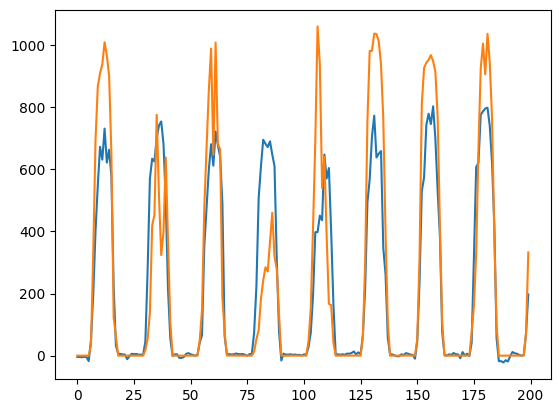

In [13]:
plt.plot(y_pred[:200])
plt.plot(test_y.to_numpy()[:200])